<div style="background: linear-gradient(135deg, #ff6eb4 0%, #ff85c1 50%, #ffaad4 100%); padding: 44px 36px 36px 36px; border-radius: 20px; text-align: center; box-shadow: 0 8px 32px rgba(220, 50, 130, 0.30); margin-bottom: 6px; box-sizing: border-box; width: 100%;">
  <p style="color: #fff0f8; font-size: 1.05em; letter-spacing: 3px; text-transform: uppercase; margin: 0 0 10px 0;"> Camada Física da Computação</p>
  <h1 style="color: white; font-size: 2.6em; margin: 0 0 10px 0; letter-spacing: 1px; text-shadow: 0 2px 8px rgba(150,0,70,0.25); font-weight: 800;">Exercícios: Modulação & Demodulação AM</h1>
  <hr style="border: none; border-top: 2px solid rgba(255,255,255,0.4); margin: 16px 60px;"/>
  <p style="color: #ffe4f4; font-size: 1.1em; margin: 0 0 4px 0;">Prof. Rodrigo Carareto · Engenharia da Computação</p>
</div>

---

###  Imports & Configurações Gerais

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display
from scipy.signal import butter, filtfilt

---

### Exercício 1 

<div style="background:#fff0f7; color:black; border-left: 5px solid #e91e8c; padding: 14px 18px; border-radius: 6px; box-sizing: border-box; width: 100%;">

Construa uma senoide de frequência **2 kHz**. Considere que essa senoide seja sua informação a ser transmitida. Considere também que sua **banda permitida de transmissão seja de 12 kHz a 18 kHz**. Dessa forma, a transformada de Fourier do sinal transmitido não pode apresentar componentes (harmônicos) fora desse intervalo.

Construa então uma **portadora de 15 kHz** e some à sua senoide que representa a informação. Faça a transformada de Fourier do sinal resultante da soma e **verifique que esse sinal não pode ser enviado**, pois não está na banda de transmissão.

Utilize **taxa de amostragem de 44100 Hz**. Apresente os gráficos.

</div>

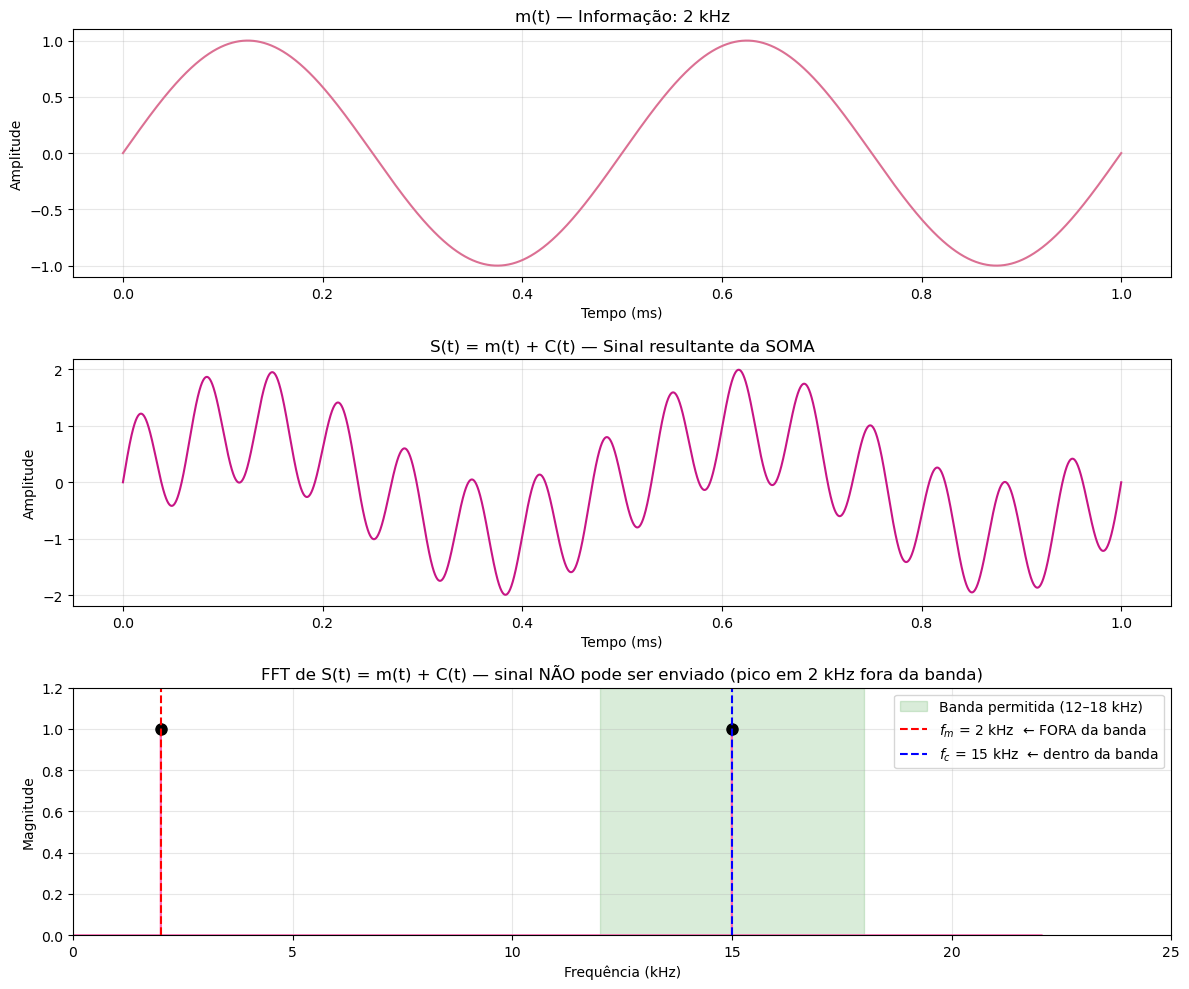

PICOS ENCONTRADOS NA FFT:
  2.0 kHz  →  FORA da banda permitida (12–18 kHz)
  15.0 kHz  →  DENTRO da banda permitida (12–18 kHz)


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
fs    = 44100   # taxa de amostragem em Hz
T     = 2.0     # duração do sinal em segundos
fm    = 2000    # frequência da informação em Hz
fc    = 15000   # frequência da portadora em Hz
f_min = 12000   # limite inferior da banda permitida
f_max = 18000   # limite superior da banda permitida

# 1. Vetor de tempo
t = np.arange(0, T, 1/fs)

# 2. Sinais
m = np.sin(2 * np.pi * fm * t)   # informação m(t) — 2 kHz
C = np.sin(2 * np.pi * fc * t)   # portadora C(t) — 15 kHz

# 3. Sinal resultante da SOMA (não modulação!)
S_soma = m + C

# 4. FFT do sinal somado
N         = len(S_soma)
fft_S     = np.fft.fft(S_soma)
freqs     = np.fft.fftfreq(N, d=1/fs)
metade    = N // 2
freqs_pos = freqs[:metade]
magnitude = (2 / N) * np.abs(fft_S[:metade])

# 5. Gráficos
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

t_plot = np.linspace(0, 0.001, 10000)   # 1 ms para visualização

# Subplot 1: m(t) no tempo
m_plot = np.sin(2 * np.pi * fm * t_plot)
axes[0].plot(t_plot * 1000, m_plot, color='palevioletred', lw=1.5)
axes[0].set_title("m(t) — Informação: 2 kHz")
axes[0].set_xlabel("Tempo (ms)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

# Subplot 2: sinal somado S(t) = m(t) + C(t) no tempo
m_p = np.sin(2 * np.pi * fm * t_plot)
C_p = np.sin(2 * np.pi * fc * t_plot)
axes[1].plot(t_plot * 1000, m_p + C_p, color='mediumvioletred', lw=1.5)
axes[1].set_title("S(t) = m(t) + C(t) — Sinal resultante da SOMA")
axes[1].set_xlabel("Tempo (ms)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

# Subplot 3: FFT do sinal somado
axes[2].plot(freqs_pos / 1000, magnitude, color='hotpink', lw=1.5)

# Marcadores nos picos: 2 kHz e 15 kHz
for f_pico in [fm, fc]:
    idx = np.argmin(np.abs(freqs_pos - f_pico))
    axes[2].plot(freqs_pos[idx] / 1000, magnitude[idx], 'o', color='black', ms=8)

# Banda permitida em verde
axes[2].axvspan(f_min / 1000, f_max / 1000,
                alpha=0.15, color='green', label='Banda permitida (12–18 kHz)')

# Linhas verticais nos picos
axes[2].axvline(fm / 1000, color='red', lw=1.5, linestyle='--',
                label=f'$f_m$ = {fm // 1000} kHz  ← FORA da banda')
axes[2].axvline(fc / 1000, color='blue', lw=1.5, linestyle='--',
                label=f'$f_c$ = {fc // 1000} kHz  ← dentro da banda')

axes[2].set_title("FFT de S(t) = m(t) + C(t) — sinal NÃO pode ser enviado (pico em 2 kHz fora da banda)")
axes[2].set_xlabel("Frequência (kHz)")
axes[2].set_ylabel("Magnitude")
axes[2].set_xlim(0, 25)
axes[2].set_ylim(0, 1.2)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Confirmação dos picos
picos_idx  = np.argsort(magnitude)[-2:]
picos_freq = sorted(freqs_pos[picos_idx] / 1000)
print("PICOS ENCONTRADOS NA FFT:")
for f in picos_freq:
    dentro = f_min/1000 <= f <= f_max/1000
    print(f"  {f:.1f} kHz  →  {'DENTRO' if dentro else 'FORA'} da banda permitida ({f_min//1000}–{f_max//1000} kHz)")

Observamos na prática por que a soma de sinais não é uma técnica válida de modulação. Ao somar a informação $m(t) (2 kHz)$ com a portadora $C(t) (15 kHz)$, a FFT do sinal resultante revelou dois picos distintos — um em cada frequência original. Isso significa que o sinal somado preserva as frequências dos dois sinais separadamente, incluindo os $2 kHz$ da informação, que estão completamente fora da banda de transmissão permitida $(12–18 kHz)$. Portanto, esse sinal não poderia ser enviado por uma antena operando nessa faixa sem violar os limites do espectro.

---

### Exercício 2

<div style="background:#fff0f7; color:black; border-left: 5px solid #e91e8c; padding: 14px 18px; border-radius: 6px; box-sizing: border-box; width: 100%;">

Considere o exemplo do exercício 1, onde o sinal contendo a informação $m(t)$ seja uma senoide de frequência **2 kHz** e a portadora seja uma senoide de **15 kHz**.

Nesse caso, qual seria a **banda mínima** para a transmissão desse sinal modulado em AM através da simples **multiplicação entre os sinais**?

</div>

##### Resolução

A modulação AM é feita pela **multiplicação** entre o sinal de informação $m(t)$ e a portadora $C(t)$:

$$S(t) = m(t) \cdot C(t) = \sin(2\pi f_m t) \cdot \sin(2\pi f_c t)$$

1. Usando as identidades trigonométricas:

$$\sin(a) = \cos(a + \phi)$$

$$\sin(a) \cdot \cos(b) = \frac{1}{2}\left(\sin(a+b) + \sin(a-b)\right)$$

2. Reescrevendo $\sin(2\pi f_c t)$ como $\cos(2\pi f_c t + \phi)$ e aplicando a identidade:

$$S(t) = \frac{1}{2}\sin\left(2\pi(f_c + f_m)t\right) + \frac{1}{2}\sin\left(2\pi(f_c - f_m)t\right)$$

3. Calculando as frequências resultantes

Com $f_m = 2\,\text{kHz}$ e $f_c = 15\,\text{kHz}$:

| Componente | Cálculo | Resultado |
|:---|:---:|:---:|
| Frequência superior | $f_c + f_m = 15 + 2$ | $17\,\text{kHz}$ |
| Frequência inferior | $f_c - f_m = 15 - 2$ | $13\,\text{kHz}$ |

4. Banda mínima necessária

$$\text{Banda mínima} = [f_c - f_m \;;\; f_c + f_m] = [13\,\text{kHz} \;;\; 17\,\text{kHz}]$$

$$\text{Largura} = 2 \cdot f_m = 2 \times 2\,\text{kHz} = \boxed{4\,\text{kHz}}$$

**Conclusão:**
Como ambas as frequências resultantes (13 e 17 kHz) estão **dentro** da banda permitida
(12–18 kHz), o sinal modulado por multiplicação **pode** ser transmitido — ao contrário
da soma, que deixava o componente de 2 kHz fora da banda.

---

### Exercício 3 

<div style="background:#fff0f7; color:black; border-left: 5px solid #e91e8c; padding: 14px 18px; border-radius: 6px; box-sizing: border-box; width: 100%;">

Construa os sinais $m(t)$ e $C(t)$ com os valores do exercício anterior (**2 kHz** e **15 kHz**). Utilize sinais com **2 segundos de duração** e **amostragem de 44100 Hz**.

Construa então o sinal modulado **multiplicando ponto a ponto** os sinais, obtendo:

$$S(t) = C(t) \cdot m(t)$$

Faça o gráfico da transformada de Fourier da multiplicação e observe que as componentes estão dentro do **intervalo mínimo (banda permitida)**.

</div>

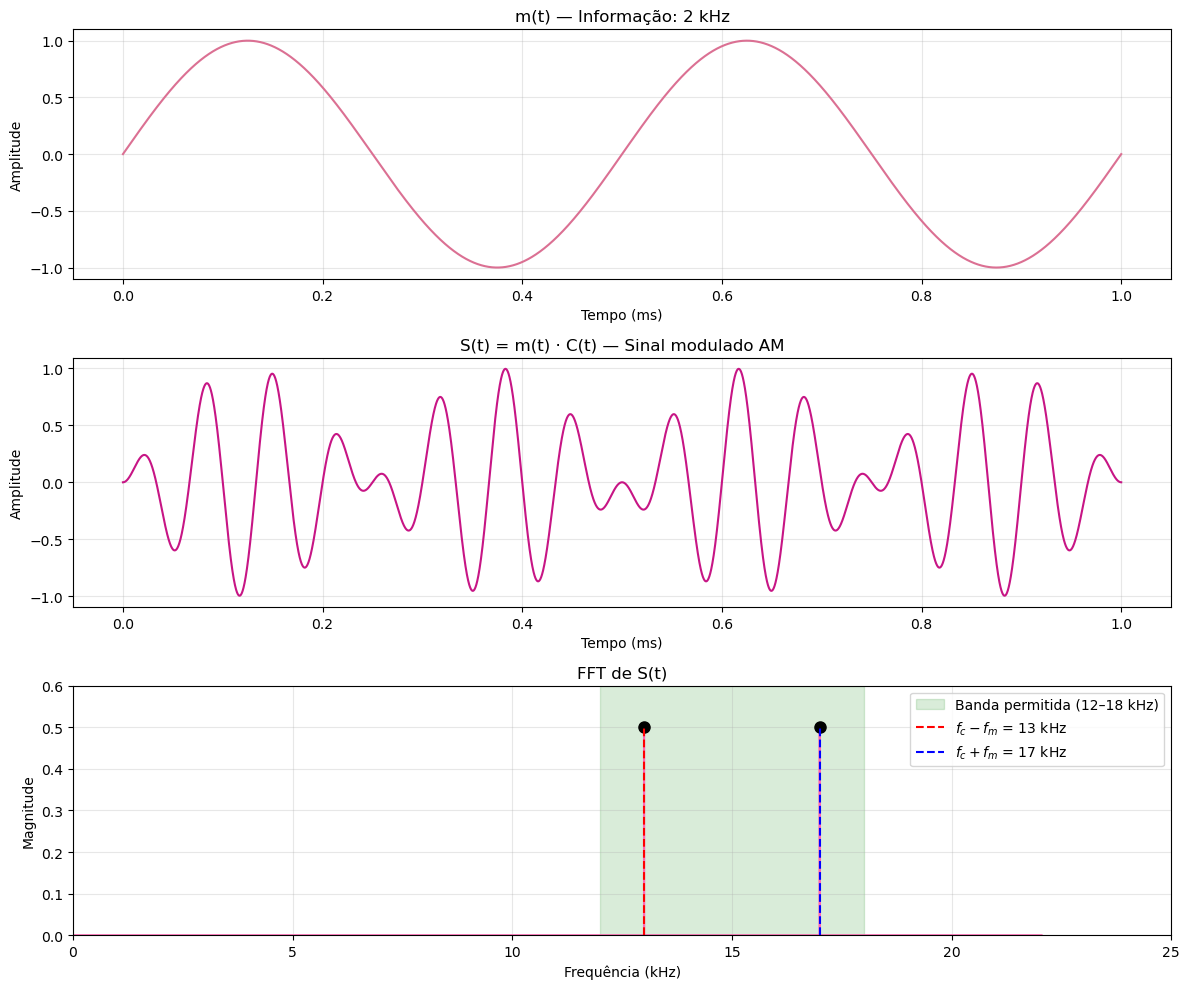

PICOS ENCONTRADOS NA FFT:
13.0 kHz
17.0 kHz


In [3]:
# Parâmetros
fs = 44100 # taxa de amostragem em Hz
T = 2.0 # duracao do sinal em segundos
fm = 2000 #frequência da informacao em Hz
fc = 15000 # frequencia da portadora
f_min = 12000 # limite inf da banda permitida
f_max = 18000 # limite sup da banda permitida

# 1. construir vetor de tempo
t = np.arange(0, T, 1/fs)

# 2. costruindo os sinais
m = np.sin(2*np.pi*fm*t) # 2. sinal de informação m(t) - 2kHz
C = np.sin(2*np.pi*fc*t) # portadora C(t) - 15kHz

# 3. contruindo o sinal modulado
S = C * m

# 4. FFT do sinal modulado
N         = len(S)
fft_S     = np.fft.fft(S)
freqs     = np.fft.fftfreq(N, d=1/fs)
metade    = N // 2
freqs_pos = freqs[:metade]
magnitude = (2 / N) * np.abs(fft_S[:metade])

# 5. gráficos
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Subplot 1: m(t) no tempo
t_plot = np.linspace(0, 0.001, 10000)  
m_plot = np.sin(2 * np.pi * fm * t_plot)
axes[0].plot(t_plot * 1000, m_plot, color='palevioletred', lw=1.5)
axes[0].set_title("m(t) — Informação: 2 kHz")
axes[0].set_xlabel("Tempo (ms)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

# Subplot 2: sinal modulado S(t) no tempo
S_plot = np.sin(2 * np.pi * fm * t_plot) * np.sin(2 * np.pi * fc * t_plot)
axes[1].plot(t_plot * 1000, S_plot, color='mediumvioletred', lw=1.5)
axes[1].set_title("S(t) = m(t) · C(t) — Sinal modulado AM")
axes[1].set_xlabel("Tempo (ms)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

# Subplot 3: FFT do sinal modulado
# marcadores nos picos para ficarem visíveis mesmo sendo bins estreitos
axes[2].plot(freqs_pos / 1000, magnitude, color='hotpink', lw=1.5)
for f_pico in [fc - fm, fc + fm]:
    idx = np.argmin(np.abs(freqs_pos - f_pico))
    axes[2].plot(freqs_pos[idx] / 1000, magnitude[idx], 'o', color='black', ms=8)

# Banda permitida em verde
axes[2].axvspan(f_min/1000, f_max/1000,
                alpha=0.15, color='green', label='Banda permitida (12–18 kHz)')

# Linhas nos picos esperados: fc - fm = 13 kHz  e  fc + fm = 17 kHz
axes[2].axvline((fc - fm)/1000, color='red', lw=1.5, linestyle='--',
                ymax=0.5/0.6,  # para na altura de 0.5 (que é 83% do ylim de 0.6)
                label=f'$f_c - f_m$ = {(fc-fm)//1000} kHz')
axes[2].axvline((fc + fm)/1000, color='blue', lw=1.5, linestyle='--',
                ymax=0.5/0.6,
                label=f'$f_c + f_m$ = {(fc+fm)//1000} kHz')

axes[2].set_title("FFT de S(t)")
axes[2].set_xlabel("Frequência (kHz)")
axes[2].set_ylabel("Magnitude")
axes[2].set_xlim(0, 25)
axes[2].set_ylim(0, 0.6)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. confirmação dos picos
# encontra os índices dos dois maiores picos no espectro
picos_idx = np.argsort(magnitude)[-2:]
picos_freq = freqs_pos[picos_idx] / 1000   # em kHz

print("PICOS ENCONTRADOS NA FFT:")
for f in sorted(picos_freq):
    print(f"{f:.1f} kHz")

Interpretação:

- Comportamento do sinal modulado: a portadora de 15kHz oscila mas a amplitude das oscilações varia, seguindo o 

---

### Exercício 4

<div style="background:#fff0f7; color:black; border-left: 5px solid #e91e8c; padding: 14px 18px; border-radius: 6px; box-sizing: border-box; width: 100%;">

Considere agora que o sinal contendo a informação $m(t)$ seja composto por muitas senoides cujas frequências **variam de 20 Hz até 2000 Hz**.

Sendo a portadora uma senoide de **15 kHz** e a banda permitida para a transmissão sendo de **14 kHz a 16 kHz**, o que poderia ser feito com o sinal $m(t)$ **antes da modulação** para podermos modulá-lo dentro da banda permitida?

</div>

Dados do problema:

- $m(t)$: composto por senódes de $20Hz$ a $2000Hz$
- Portadora: $15kHz$
- Banda permitida: $14kHz$ a $16kHz$ $––$ largura de banda = $2kHz$

Ao fazermos modulação AM por multiplicação, o espectro de $m(t)$ é transladado simetricamente a redor da frequência da portadora, gerando duas bandas laterais: uma superior $fc+fm$ e uma inferior: $fc - fm$. Com $m(t)$ ocupando até $2kHz$, o sinal modulado resultante cobriria de $13kHz$ a $17kHz$, como calculamos no item anterior, e isso ultrapassa a banda permitida em ambos os lados.

A banda de $14kHz$ a $16kHz$ permite apenas $+-1kHz$ em torno da portadora de $15kHz$. Então para que o sinal modulado caiba dentro dessa faixa, podemos aplicar sobre $m(t)$ um filtro passa-baixa com frequência de corte em $1kHz$ antes da modulação. Com isso, as bandas laterais geradas após a multiplicação pela portadora ficam limitadas à:
- $14 kHz–15 kHz$ (banda inferior)
- $15 kHz–16 kHz$ (banda superior)

Isso respeita a banda de transmissão permitida, evitando interferência com outros canais.


---

### Exercício 5

<div style="background:#fff0f7; color:black; border-left: 5px solid #e91e8c; padding: 14px 18px; border-radius: 6px; box-sizing: border-box; width: 100%;">

Para esse exercício, use um **arquivo de áudio de poucos segundos**.

1. Examine o gráfico da transformada de Fourier desse áudio e repare na faixa (banda) de frequências que o sinal ocupa. **Execute o áudio.**
2. Gere uma **portadora de 16 kHz** com exatamente o mesmo número de pontos que o sinal.
3. Module o sinal em AM por multiplicação, de modo que o sinal modulado esteja dentro da faixa de **14 kHz a 18 kHz**. Note que talvez você precise tratar o sinal original antes da modulação.
4. Faça o gráfico de Fourier do sinal modulado e **verifique se está dentro da banda**.
5. **Execute o áudio do sinal modulado.**
6. Demodule o sinal através da multiplicação e aplique o **filtro passa-baixa**.
7. Faça o gráfico da transformada de Fourier do sinal demodulado e verifique que o sinal original foi **recuperado**.
8. **Execute o sinal demodulado.**

</div>

#### 5.1 — Carregamento e análise do áudio original

In [9]:
# gerando áudio sintético
fs = 44100
duration = 3
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

audio = audio = (0.4 * np.sin(2 * np.pi * 440  * t) +
         0.3 * np.sin(2 * np.pi * 880  * t) +
         0.2 * np.sin(2 * np.pi * 1200 * t) +
         0.15 * np.sin(2 * np.pi * 3000 * t) +  
         0.1 * np.sin(2 * np.pi * 5000 * t))

audio = audio / np.max(np.abs(audio)) * 0.9
wavfile.write('audio_ex5.wav', fs, (audio * 32767).astype(np.int16))
print("Áudio gerado!")

Áudio gerado!


Taxa de amostragem: 44100 Hz | Amostras: 132300 | Duração: 3.00 s


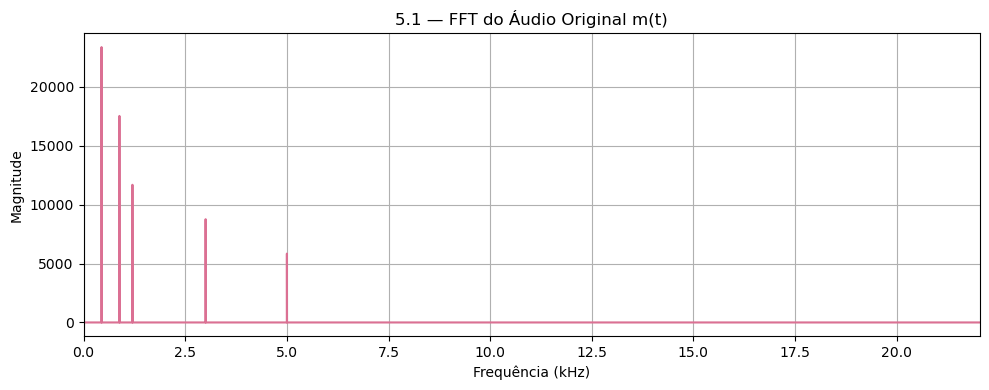

In [12]:
fs, data = wavfile.read('audio_ex5.wav')
# Normalizar para float
if data.dtype == np.int16:
    m_original = data.astype(np.float64) / 32767.0
elif data.dtype == np.int32:
    m_original = data.astype(np.float64) / 2147483647.0
else:
    m_original = data.astype(np.float64)

# Se estéreo, pegar apenas canal esquerdo
if m_original.ndim == 2:
    m_original = m_original[:, 0]

N = len(m_original)
t = np.linspace(0, N / fs, N, endpoint=False)

print(f"Taxa de amostragem: {fs} Hz | Amostras: {N} | Duração: {N/fs:.2f} s")

# FFT
freqs = np.fft.rfftfreq(N, d=1/fs)
mag   = np.abs(np.fft.rfft(m_original))

plt.figure(figsize=(10, 4))
plt.plot(freqs / 1000, mag, color='palevioletred')
plt.title("5.1 — FFT do Áudio Original m(t)")
plt.xlabel("Frequência (kHz)")
plt.ylabel("Magnitude")
plt.xlim(0, fs / 2000)
plt.grid(True)
plt.tight_layout()
plt.show()

display(Audio(m_original, rate=fs))

É possível observar que o sinal possui componentes de frequência em $440 Hz$, $880 Hz$, $1200 Hz$, $3000 Hz$ e $5000 Hz$, ocupando uma banda de 0 a 5 kHz. 

As componentes de $3000 Hz$ e $5000 Hz$ estão acima do limite de $2 kHz$ imposto pela banda de transmissão permitida ($14–18 kHz$ com portadora de $16 kHz$), então precisarão ser removidas antes da modulação.

#### 5.2 — Geração da portadora e pré-processamento de m(t)

Portadora: 16.0 kHz | Pré-filtro passa-baixa: corte = 2.0 kHz


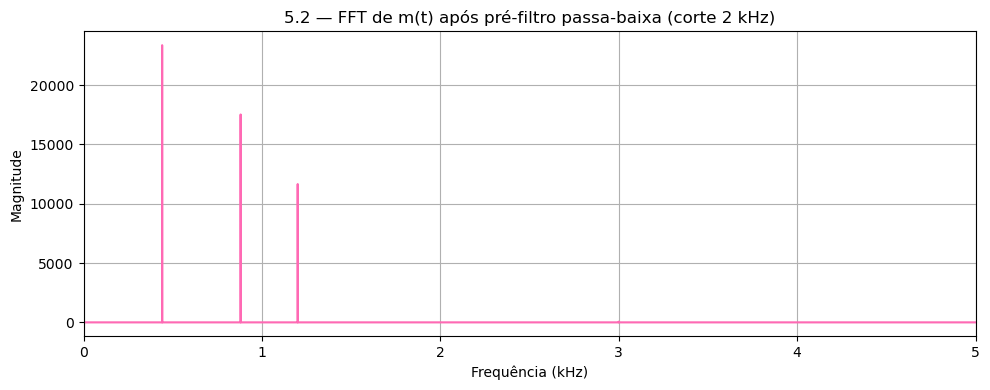

In [14]:
fc      = 16000   # portadora 16 kHz  →  banda: 14 kHz a 18 kHz
f_corte = 2000    # corte do pré-filtro: fc ± 2 kHz cabe na banda

# Portadora com mesmo número de pontos que o sinal
portadora = np.sin(2 * np.pi * fc * t)

# Pré-filtro passa-baixa em m(t) — corte em 2 kHz
order = 6
b, a  = butter(order, f_corte / (fs / 2), btype='low')
m_filtrado = filtfilt(b, a, m_original)

print(f"Portadora: {fc/1000} kHz | Pré-filtro passa-baixa: corte = {f_corte/1000} kHz")

# FFT de m(t) filtrado para conferência
mag_mf = np.abs(np.fft.rfft(m_filtrado))

plt.figure(figsize=(10, 4))
plt.plot(freqs / 1000, mag_mf, color='hotpink')
plt.title("5.2 — FFT de m(t) após pré-filtro passa-baixa (corte 2 kHz)")
plt.xlabel("Frequência (kHz)")
plt.ylabel("Magnitude")
plt.xlim(0, 5)
plt.grid(True)
plt.tight_layout()
plt.show()

O sinal filtrado manteve apenas os três componentes abaixo da freq. de corte de $2kHz$, eliminando as componentes de $3kHz$ e $5kHz$. Assim, após a modulação, o sinal transmitido caberá dentro da banda permitida de $14kHz$ a $18kHz$.

#### 5.3 — Modulação AM, FFT e execução do sinal modulado

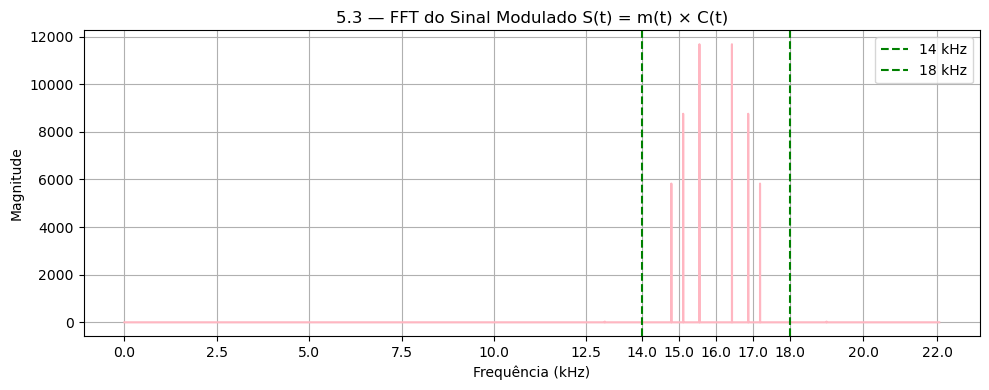

In [18]:
# S(t) = m_filtrado(t) × C(t)
S = m_filtrado * portadora

mag_S = np.abs(np.fft.rfft(S))

plt.figure(figsize=(10, 4))
plt.plot(freqs / 1000, mag_S, color='lightpink')
plt.title("5.3 — FFT do Sinal Modulado S(t) = m(t) × C(t)")
plt.xlabel("Frequência (kHz)")
plt.ylabel("Magnitude")
plt.xticks([0, 2.5, 5, 7.5, 10, 12.5, 14, 15, 16, 17, 18, 20, 22])
plt.axvline(14, color='green', linestyle='--', linewidth=1.5, label='14 kHz')
plt.axvline(18, color='green', linestyle='--', linewidth=1.5, label='18 kHz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

S_audio = S / np.max(np.abs(S)) * 0.9
display(Audio(S_audio, rate=fs))

O $m(t)$ filtrado foi multiplicado pela portadora de $16kHz$, gerando o sinal modulado $S(t)$. Fizemos a FFT de $S(t)$ e podemos observar que todos os componentes do sinal estão dentro da banda permitida (em verde), então o pré-processamento foi eficiente.

#### 5.4 — Demodulação síncrona + filtro passa-baixa + execução

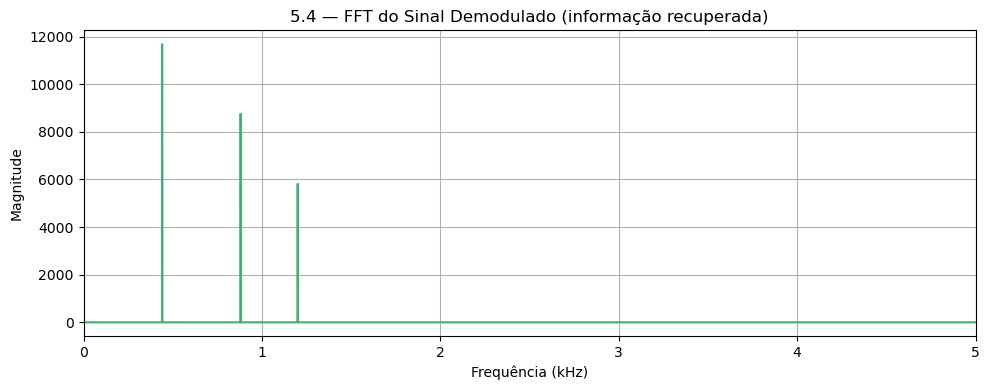

In [19]:
# Passo 1: multiplicar S(t) pela portadora novamente
S_demod = S * portadora

# Passo 2: filtro passa-baixa para eliminar componentes em 2*fc
b_d, a_d     = butter(order, f_corte / (fs / 2), btype='low')
m_recuperado = filtfilt(b_d, a_d, S_demod)

mag_dem = np.abs(np.fft.rfft(m_recuperado))

plt.figure(figsize=(10, 4))
plt.plot(freqs / 1000, mag_dem, color='mediumseagreen')
plt.title("5.4 — FFT do Sinal Demodulado (informação recuperada)")
plt.xlabel("Frequência (kHz)")
plt.ylabel("Magnitude")
plt.xlim(0, 5)
plt.grid(True)
plt.tight_layout()
plt.show()

m_rec_norm = m_recuperado / np.max(np.abs(m_recuperado)) * 0.9
display(Audio(m_rec_norm, rate=fs))

O sinal modeluado $S(t)$ foi multiplicado novamente pela portadora $16kHz$ e, em seguida, aplicamos um filtro passa-baixa com freq. de corte $2kHz$, pra eliminar as componentes de alta frequência geradas pela mutiplicação. O gráfico com os picos mostra que a informação original foi recuperada corretamente.

> Conclusão do exercício 5:
> - Na ida, aplicamos um filtro sobre o sinal original, antes da modulação, para limitar a banda do sinal de iformação.
> - Na volta: aplicamos outro filtro para eliminar os resíduos da demodulação gerados pela segunda multiplicação, recuperando apenas a informação original.

---

### Exercício 6

<div style="background:#fff0f7; color:black; border-left: 5px solid #e91e8c; padding: 14px 18px; border-radius: 6px; box-sizing: border-box; width: 100%;">

Um sinal digital foi modulado utilizando-se a técnica **64-QAM**, onde tanto a amplitude como a fase podem variar em **8 níveis** (8 possíveis fases e 8 possíveis amplitudes). Considere que a portadora utilizada foi uma onda com frequência **2,4 GHz**.

Considere ainda que, tanto na modulação quanto na demodulação, a fase e a amplitude da portadora sofriam variações apenas **a cada dois períodos**, garantindo a estabilidade de cada estado (por limitações de hardware). Assim cada conjunto de bits era modulado a cada dois períodos e o mesmo ocorreu na demodulação.

Nessas condições, **qual a taxa de transmissão possível através desse sinal modulado?**

</div>

**1. Quantidade de bits por símbolo:**

  > 64 combinações possíveis (8 amplitudes × 8 fases):  
  > $log_2(64) = 6$ bits por símbolo

**2. Período da portadora:**

>  $$T = \frac{1}{f_c} = \frac{1}{2{,}4 \times 10^9} \approx 4{,}17 \times 10^{-10} \text{ s}$$

**3. Tempo por símbolo:**
>  O estado muda a cada 2 períodos, então:
>  $$T_{símbolo} = 2 \times T = 2 \times 4{,}17 \times 10^{-10} \approx 8{,}33 \times 10^{-10} \text{ s}$$

**4. Baud Rate:**
> $$\text{Baud rate} = \frac{1}{T_{símbolo}} = \frac{1}{8{,}33 \times 10^{-10}} \approx 1{,}2 \times 10^9 \text{ símbolos/s}$$

**5. Taxa de bits**
> $$\text{Taxa} = \text{Baud rate} \times \text{bits por símbolo} = 1{,}2 \times 10^9 \times 6 = 7{,}2 \times 10^9 \text{ bps} = \textbf{7,2 Gbps}$$

Percebemos que a taxa de bits depende de 2 fatores importantes:
- Quantos bits cabem em cada símbolo: definido pela quantidade de combinações possíveis da modulação.
- Com que velocidade os símbolos são transmitidos (Baud Rate): definido pela física da portadora e pela limitação de hardware.
- Logo: **taxa de bits ≠ frequência da portadora**

---

### Exercício 7 

<div style="background:#fff0f7; color:black; border-left: 5px solid #e91e8c; padding: 14px 18px; border-radius: 6px; box-sizing: border-box; width: 100%;">

Um sinal digital foi modulado utilizando-se a técnica **256-QAM**, onde tanto a amplitude como a fase podem variar em **16 níveis**. Considere que a portadora utilizada foi uma onda com frequência **2,4 GHz**.

Considere ainda que, tanto na modulação quanto na demodulação, a fase e a amplitude da portadora sofriam variações, **no mínimo, a cada 10 períodos**.

**Quanto tempo esse sinal levaria para transmitir 480 MBytes?**

</div>

**1. Quantidade de bits por símbolo:**

  > 256 combinações possíveis (16 amplitudes × 16 fases):  
  > $log_2(256) = 8$ bits por símbolo

**2. Período da portadora:**

>  $$T = \frac{1}{f_c} = \frac{1}{2{,}4 \times 10^9} \approx 4{,}17 \times 10^{-10} \text{ s}$$

**3. Tempo por símbolo:**
>  O estado muda a cada 10 períodos, então:
>  $$T_{símbolo} = 10 \times T = 10 \times 4{,}17 \times 10^{-10} \approx 4{,}17 \times 10^{-9} \text{ s}$$

**4. Baud Rate:**
> $$\text{Baud rate} = \frac{1}{T_{símbolo}} = \frac{1}{4{,}17 \times 10^{-9}} \approx 2{,}4 \times 10^8 \text{ símbolos/s}$$

**5. Taxa de bits**
> $$\text{Taxa} = \text{Baud rate} \times \text{bits por símbolo} = 2{,}4 \times 10^8 \times 8 = 1{,}92 \times 10^9 \text{ bps} = \textbf{1,92 Gbps}$$

**6. Tempo para transmitir 480 MBytes:**

> Convertendo: $480 \text{ MB} = 480 \times 10^6 \times 8 = 3{,}84 \times 10^9 \text{ bits}$
> $$t = \frac{3{,}84 \times 10^9}{1{,}92 \times 10^9} = \textbf{2 segundos}$$

Reforça a conclusão do exercício 6, que mostra que a taxa de transmissão em QAM depende da quantidade de bits/símbolo e a velocidade de transmissão desses símbolos. Comparando os dois exs, vemos que: aumentar o número de níveis da modulação nem sempre aumenta a taxa de bits, pois o baud rate depende da limitação de hardware.